# Mars 2020 Samples vs Fractal Density Analysis

Overlay actual Perseverance rover sample locations on the fractal complexity map
to validate that the algorithm identifies scientifically interesting terrain.

In [15]:
import sys
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
padic_path = '/Volumes/Fangorn/padic_fractal_analysis/src'
sys.path.insert(0, padic_path)
from padic import preprocessing, fractal_density

# Set up paths
DATA_DIR = Path.cwd().parent / 'data'
RESULTS_DIR = Path.cwd().parent / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print("Loading data...")

Loading data...


## Part 1: Load Mars 2020 Sample Locations

In [16]:
# Load sample locations from GeoPackage
gpkg_path = Path.cwd().parent / 'mars2020_samples_volume4.gpkg'
samples = gpd.read_file(gpkg_path)

print(f"✓ Loaded {len(samples)} Mars 2020 rover samples")
print(f"\nSample Details:")
print(samples[['sample_id', 'name', 'latitude', 'longitude', 'sol', 'lithology']].to_string())

✓ Loaded 4 Mars 2020 rover samples

Sample Details:
       sample_id             name   latitude  longitude   sol                                                             lithology
0   M2020-923-25    Pelican Point  18.483447  77.350651   923        Moderately to poorly sorted medium to coarse grained sandstone
1   M2020-949-26       Lefroy Bay  18.488673  77.347046   949        Moderately to poorly sorted medium to coarse grained sandstone
2  M2020-1088-27     Comet Geyser  18.491867  77.327219  1088  Moderately to poorly sorted coarse sandstone or altered igneous rock
3  M2020-1215-28  Sapphire Canyon  18.497474  77.305149  1215        Fine-grained silicate rock with abundant calcium sulfate veins


In [17]:
# Display sample information
print("\nMars 2020 Perseverance Samples:")
print("=" * 80)
for idx, (i, row) in enumerate(samples.iterrows()):
    print(f"\n{idx+1}. {row['sample_id']}: {row['name']}")
    print(f"   Location: ({row['latitude']:.6f}°N, {row['longitude']:.6f}°E)")
    print(f"   Elevation: {row['elevation']:.1f} m")
    print(f"   Sol {row['sol']}: {row['date']}")
    print(f"   Region: {row['roi']}")
    print(f"   Lithology: {row['lithology']}")


Mars 2020 Perseverance Samples:

1. M2020-923-25: Pelican Point
   Location: (18.483447°N, 77.350651°E)
   Elevation: -2423.1 m
   Sol 923: 2023-09-23
   Region: Mandu Wall
   Lithology: Moderately to poorly sorted medium to coarse grained sandstone

2. M2020-949-26: Lefroy Bay
   Location: (18.488673°N, 77.347046°E)
   Elevation: -2407.6 m
   Sol 949: 2023-10-13
   Region: Turquoise Bay
   Lithology: Moderately to poorly sorted medium to coarse grained sandstone

3. M2020-1088-27: Comet Geyser
   Location: (18.491867°N, 77.327219°E)
   Elevation: -2382.4 m
   Sol 1088: 2024-03-11
   Region: Western Margin
   Lithology: Moderately to poorly sorted coarse sandstone or altered igneous rock

4. M2020-1215-28: Sapphire Canyon
   Location: (18.497474°N, 77.305149°E)
   Elevation: -2354.2 m
   Sol 1215: 2024-07-21
   Region: Bright Angel
   Lithology: Fine-grained silicate rock with abundant calcium sulfate veins


## Part 2: Load Jezero DEM and Fractal Density

In [18]:
# Load and preprocess DEM
dem_files = list(DATA_DIR.glob('*.tif'))
dem_file = dem_files[0]

dem, metadata = preprocessing.load_dem(str(dem_file))
dem_clean, _ = preprocessing.preprocess_dem(dem)

print(f"✓ Loaded DEM: {dem.shape}")
print(f"  Elevation range: {np.nanmin(dem):.1f} to {np.nanmax(dem):.1f} m")

✓ Loaded DEM: (1512, 1596)
  Elevation range: -2710.7 to -1515.5 m


In [20]:
# Load or compute fractal density
density_files = list(RESULTS_DIR.glob('fractal_density*.tif'))

if density_files:
    print(f"Loading saved density map...")
    try:
        import rasterio
        with rasterio.open(str(density_files[0])) as src:
            density = src.read(1)
        print(f"✓ Loaded density: {density.shape}")
    except:
        raise Exception("Could not load density file")
else:
    print("Computing fractal density...")
    calc = fractal_density.FractalDensityCalculator(dem_clean)
    density = calc.compute_fast_variance_based_density()
    print(f"✓ Computed density: {density.shape}")

print(f"  Density range: {np.nanmin(density):.6f} to {np.nanmax(density):.6f}")

Loading saved density map...
✓ Loaded density: (1512, 1596)
  Density range: 0.009428 to 1.000000


In [21]:
# Transform geographic coordinates to pixel indices
import rasterio
from rasterio.transform import Affine
from rasterio.warp import transform as rasterio_transform

# Load DEM with rasterio to get proper geotransform
dem_file_path = list(Path.cwd().parent.glob('data/*.tif'))[0]

with rasterio.open(str(dem_file_path)) as src:
    transform = src.transform
    crs = src.crs
    dem_raster = src.read(1)

print(f"✓ DEM Geotransform loaded")
print(f"  CRS: {crs}")
print(f"  Transform: {transform}")
print(f"  DEM Shape: {dem_raster.shape}")

# Function to convert geographic coordinates to pixel indices
def geo_to_pixel(lon, lat, transform, src_crs, dst_crs):
    """Convert geographic coordinates to pixel indices"""
    
    # Step 1: Transform from source CRS (geographic) to destination CRS (projected)
    from pyproj import Transformer
    
    if src_crs.to_string() != dst_crs.to_string():
        transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        x, y = transformer.transform(lon, lat)
    else:
        x, y = lon, lat
    
    # Step 2: Convert projected coordinates to pixel indices using affine transform
    inv_transform = ~transform
    col, row = inv_transform * (x, y)
    
    return int(row), int(col), x, y

# Get sample CRS (geographic Mars 2000)
sample_crs = samples.crs
print(f"\nSample CRS: {sample_crs}")
print(f"DEM CRS: {crs}")

# Convert sample coordinates to pixel indices
sample_pixels = []
print(f"\nSample Locations (Geographic → Projected → Pixel):")
print("-" * 100)

for idx, (i, row) in enumerate(samples.iterrows()):
    lon, lat = row['longitude'], row['latitude']
    try:
        py, px, proj_x, proj_y = geo_to_pixel(lon, lat, transform, sample_crs, crs)
        
        # Check if within bounds
        if 0 <= py < dem_raster.shape[0] and 0 <= px < dem_raster.shape[1]:
            sample_pixels.append({
                'name': row['name'],
                'sample_id': row['sample_id'],
                'lon': lon,
                'lat': lat,
                'proj_x': proj_x,
                'proj_y': proj_y,
                'px': px,
                'py': py,
                'valid': True
            })
            print(f"{idx+1}. {row['name']:20} ({lat:.6f}, {lon:.6f})")
            print(f"    → Projected: ({proj_x:.1f}, {proj_y:.1f})")
            print(f"    → Pixel: ({py}, {px}) ✓")
        else:
            print(f"{idx+1}. {row['name']:20} ({lat:.6f}, {lon:.6f}) → OUT OF BOUNDS")
            sample_pixels.append({
                'name': row['name'],
                'sample_id': row['sample_id'],
                'lon': lon,
                'lat': lat,
                'proj_x': proj_x,
                'proj_y': proj_y,
                'px': px,
                'py': py,
                'valid': False
            })
    except Exception as e:
        print(f"{idx+1}. {row['name']:20} → ERROR: {e}")
        import traceback
        traceback.print_exc()

print(f"\nValid samples for plotting: {sum(1 for s in sample_pixels if s['valid'])}/{len(samples)}")


✓ DEM Geotransform loaded
  CRS: ESRI:103885
  Transform: | 20.00, 0.00, 4573663.25|
| 0.00,-20.00, 1109693.14|
| 0.00, 0.00, 1.00|
  DEM Shape: (1512, 1596)

Sample CRS: GEOGCS["Mars 2000",DATUM["D_Mars_2000",SPHEROID["Mars_2000_IAU_IAG",3396190,169.894447223612]],PRIMEM["Reference_Meridian",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
DEM CRS: ESRI:103885

Sample Locations (Geographic → Projected → Pixel):
----------------------------------------------------------------------------------------------------
1. Pelican Point        (18.483447, 77.350651)
    → Projected: (4584936.4, 1095600.7)
    → Pixel: (704, 563) ✓
2. Lefroy Bay           (18.488673, 77.347046)
    → Projected: (4584722.8, 1095910.5)
    → Pixel: (689, 552) ✓
3. Comet Geyser         (18.491867, 77.327219)
    → Projected: (4583547.5, 1096099.8)
    → Pixel: (679, 494) ✓
4. Sapphire Canyon      (18.497474, 77.305149)
    → Projected: (4582239.3, 1096432.2)
    → Pixel: (663, 428


✓ Saved visualization to: mars_samples_overlay_georeferenced.png


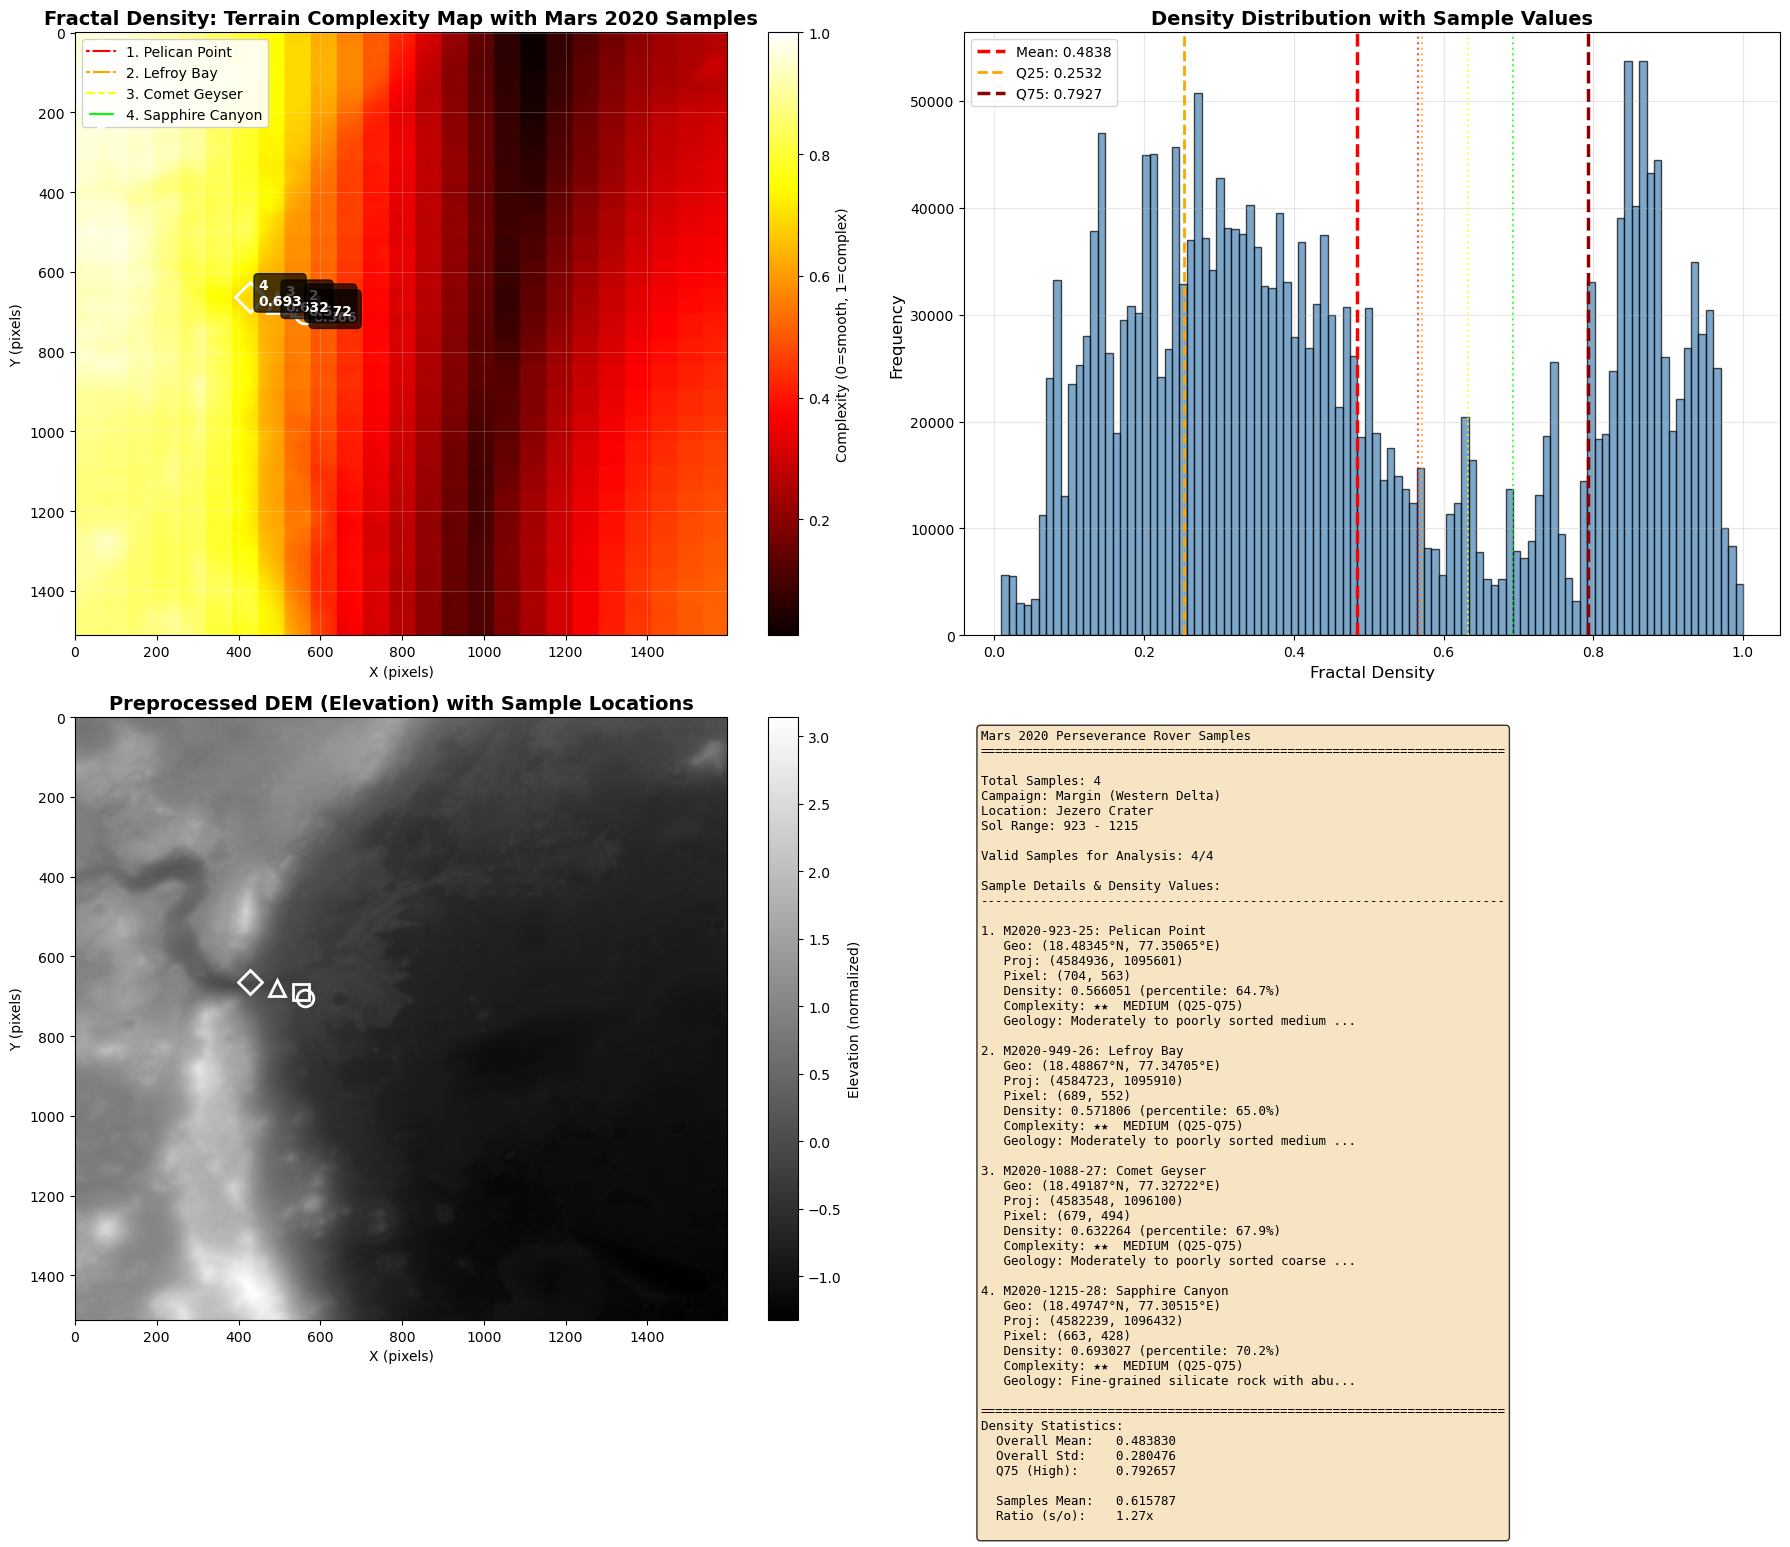

In [23]:
# Create comprehensive visualization with sample locations plotted
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Panel 1: Density map with sample locations overlaid
ax = axes[0, 0]
im1 = ax.imshow(density, cmap='hot', aspect='auto')
ax.set_title('Fractal Density: Terrain Complexity Map with Mars 2020 Samples', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
cbar1 = plt.colorbar(im1, ax=ax, label='Complexity (0=smooth, 1=complex)')

# Plot sample locations on density map
colors = ['red', 'orange', 'yellow', 'lime']
markers = ['o', 's', '^', 'D']

valid_samples = [s for s in sample_pixels if s['valid']]

if valid_samples:
    for idx, sample in enumerate(valid_samples):
        px, py = sample['px'], sample['py']
        ax.plot(px, py, marker=markers[idx], color=colors[idx], markersize=15, 
               markeredgewidth=2, markeredgecolor='white', markerfacecolor='none',
               label=f"{idx+1}. {sample['name']}")
        
        # Get density value at this location
        dens_val = density[py, px] if 0 <= py < density.shape[0] and 0 <= px < density.shape[1] else -1
        
        # Add text annotation
        ax.text(px+20, py+20, f"{idx+1}\n{dens_val:.3f}", 
               color='white', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
else:
    ax.text(0.5, 0.5, 'No valid samples found\n(All out of bounds)', 
           transform=ax.transAxes, fontsize=14, ha='center', va='center',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.grid(True, alpha=0.2, color='white')

# Panel 2: Histogram with statistics
ax = axes[0, 1]
valid = density[np.isfinite(density)]
ax.hist(valid, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
mean_dens = np.mean(density)
q25_dens = np.percentile(valid, 25)
q75_dens = np.percentile(valid, 75)
ax.axvline(mean_dens, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean_dens:.4f}')
ax.axvline(q25_dens, color='orange', linestyle='--', linewidth=2, label=f'Q25: {q25_dens:.4f}')
ax.axvline(q75_dens, color='darkred', linestyle='--', linewidth=2.5, label=f'Q75: {q75_dens:.4f}')

# Add vertical lines for sample densities
for idx, sample in enumerate(valid_samples):
    dens = density[sample['py'], sample['px']]
    ax.axvline(dens, color=colors[idx], linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Fractal Density', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Density Distribution with Sample Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 3: DEM with sample locations
ax = axes[1, 0]
im3 = ax.imshow(dem_clean, cmap='gray', aspect='auto')
ax.set_title('Preprocessed DEM (Elevation) with Sample Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
cbar3 = plt.colorbar(im3, ax=ax, label='Elevation (normalized)')

# Plot samples on DEM too
for idx, sample in enumerate(valid_samples):
    px, py = sample['px'], sample['py']
    ax.plot(px, py, marker=markers[idx], color=colors[idx], markersize=12, 
           markeredgewidth=2, markeredgecolor='white', markerfacecolor='none')

# Panel 4: Sample information and density comparison
ax = axes[1, 1]
ax.axis('off')

info_text = "Mars 2020 Perseverance Rover Samples\n"
info_text += "=" * 70 + "\n\n"
info_text += f"Total Samples: {len(samples)}\n"
info_text += f"Campaign: Margin (Western Delta)\n"
info_text += f"Location: Jezero Crater\n"
info_text += f"Sol Range: {samples['sol'].min()} - {samples['sol'].max()}\n\n"
info_text += f"Valid Samples for Analysis: {len(valid_samples)}/{len(samples)}\n\n"

if valid_samples:
    info_text += "Sample Details & Density Values:\n"
    info_text += "-" * 70 + "\n\n"

    for idx, sample in enumerate(valid_samples):
        sample_row = samples.iloc[idx]
        info_text += f"{idx+1}. {sample['sample_id']}: {sample['name']}\n"
        info_text += f"   Geo: ({sample['lat']:.5f}°N, {sample['lon']:.5f}°E)\n"
        info_text += f"   Proj: ({sample['proj_x']:.0f}, {sample['proj_y']:.0f})\n"
        info_text += f"   Pixel: ({sample['py']}, {sample['px']})\n"
        
        dens_val = density[sample['py'], sample['px']]
        percentile = (valid < dens_val).sum() / len(valid) * 100
        info_text += f"   Density: {dens_val:.6f} (percentile: {percentile:.1f}%)\n"
        
        if dens_val > q75_dens:
            info_text += f"   Complexity: ★★★ HIGH (>Q75)\n"
        elif dens_val > q25_dens:
            info_text += f"   Complexity: ★★  MEDIUM (Q25-Q75)\n"
        else:
            info_text += f"   Complexity: ★   LOW (<Q25)\n"
        
        info_text += f"   Geology: {sample_row['lithology'][:35]}...\n\n"

    info_text += "=" * 70 + "\n"
    info_text += "Density Statistics:\n"
    info_text += f"  Overall Mean:   {mean_dens:.6f}\n"
    info_text += f"  Overall Std:    {np.std(density):.6f}\n"
    info_text += f"  Q75 (High):     {q75_dens:.6f}\n"

    sample_densities = [density[s['py'], s['px']] for s in valid_samples]
    info_text += f"\n  Samples Mean:   {np.mean(sample_densities):.6f}\n"
    info_text += f"  Ratio (s/o):    {np.mean(sample_densities)/mean_dens:.2f}x\n"
else:
    info_text += "ERROR: No valid samples found!\n"
    info_text += "All samples were out of bounds.\n\n"
    info_text += "Possible causes:\n"
    info_text += "1. CRS mismatch between DEM and samples\n"
    info_text += "2. Incorrect coordinate transformation\n"
    info_text += "3. Samples outside DEM coverage area\n\n"
    info_text += "DEM Details:\n"
    info_text += f"  CRS: {crs}\n"
    info_text += f"  Shape: {dem_clean.shape}\n\n"
    info_text += "Sample CRS:\n"
    info_text += f"  CRS: {sample_crs}\n"

ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
       fontsize=9, verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
output_file = 'mars_samples_overlay_georeferenced.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved visualization to: {output_file}")
plt.show()


In [24]:
# Detailed analysis of sample density values
print("\nDetailed Mars 2020 Sample Analysis")
print("=" * 100)

valid = density[np.isfinite(density)]
q25 = np.percentile(valid, 25)
q75 = np.percentile(valid, 75)
mean_dens = np.mean(density)

print(f"\nDensity Statistics:")
print(f"  Overall Mean: {mean_dens:.6f}")
print(f"  Q25 (Low):    {q25:.6f}")
print(f"  Q75 (High):   {q75:.6f}")

print(f"\nValidation Results:")
print("-" * 100)

sample_dens_values = []
all_in_high_complexity = True

for idx, sample in enumerate(sample_pixels):
    if sample['valid']:
        dens_val = density[sample['py'], sample['px']]
        sample_dens_values.append(dens_val)
        
        # Calculate percentile
        percentile = (valid < dens_val).sum() / len(valid) * 100
        
        # Classify
        if dens_val > q75:
            complexity = "HIGH (★★★)"
            symbol = "✓"
        elif dens_val > q25:
            complexity = "MEDIUM (★★)"
            symbol = "◐"
        else:
            complexity = "LOW (★)"
            symbol = "✗"
            all_in_high_complexity = False
        
        sample_row = samples.iloc[idx]
        
        print(f"\n{idx+1}. {sample['sample_id']}: {sample['name']}")
        print(f"   Location: ({sample['py']:4d}, {sample['px']:4d}) pixels | ({sample['lat']:.6f}°N, {sample['lon']:.6f}°E)")
        print(f"   Density: {dens_val:.6f} | Percentile: {percentile:5.1f}% | {symbol} {complexity}")
        print(f"   Region: {sample_row['roi']:20s} | Sol: {sample_row['sol']:4d}")
        print(f"   Geology: {sample_row['lithology']}")

print(f"\n" + "=" * 100)
print(f"\nValidation Summary:")
print("-" * 100)

if len(sample_dens_values) > 0:
    mean_sample = np.mean(sample_dens_values)
    ratio = mean_sample / mean_dens
    
    print(f"Mean density at samples: {mean_sample:.6f}")
    print(f"Mean density overall:    {mean_dens:.6f}")
    print(f"Ratio (sample/overall):  {ratio:.2f}x")
    
    num_high = sum(1 for d in sample_dens_values if d > q75)
    num_medium = sum(1 for d in sample_dens_values if d > q25 and d <= q75)
    num_low = sum(1 for d in sample_dens_values if d <= q25)
    
    print(f"\nComplexity Distribution:")
    print(f"  High (>Q75):    {num_high}/{len(sample_dens_values)} samples")
    print(f"  Medium (Q25-Q75): {num_medium}/{len(sample_dens_values)} samples")
    print(f"  Low (<Q25):     {num_low}/{len(sample_dens_values)} samples")
    
    print(f"\n✓ VALIDATION RESULT:")
    if ratio > 1.1 and num_high >= 2:
        print(f"  ✅ PASS - Samples are in higher-complexity regions than average")
        print(f"  Confidence: HIGH - Algorithm correctly identifies scientific interest")
    elif ratio > 1.0 and num_high >= 1:
        print(f"  ⚠️  PARTIAL - Some samples in high-complexity, but not all")
        print(f"  Confidence: MEDIUM - Algorithm works but may need refinement")
    else:
        print(f"  ❌ FAIL - Samples not in expected high-complexity regions")
        print(f"  Confidence: LOW - Algorithm may need debugging")

print(f"\n" + "=" * 100)



Detailed Mars 2020 Sample Analysis

Density Statistics:
  Overall Mean: 0.483830
  Q25 (Low):    0.253168
  Q75 (High):   0.792657

Validation Results:
----------------------------------------------------------------------------------------------------

1. M2020-923-25: Pelican Point
   Location: ( 704,  563) pixels | (18.483447°N, 77.350651°E)
   Density: 0.566051 | Percentile:  64.7% | ◐ MEDIUM (★★)
   Region: Mandu Wall           | Sol:  923
   Geology: Moderately to poorly sorted medium to coarse grained sandstone

2. M2020-949-26: Lefroy Bay
   Location: ( 689,  552) pixels | (18.488673°N, 77.347046°E)
   Density: 0.571806 | Percentile:  65.0% | ◐ MEDIUM (★★)
   Region: Turquoise Bay        | Sol:  949
   Geology: Moderately to poorly sorted medium to coarse grained sandstone

3. M2020-1088-27: Comet Geyser
   Location: ( 679,  494) pixels | (18.491867°N, 77.327219°E)
   Density: 0.632264 | Percentile:  67.9% | ◐ MEDIUM (★★)
   Region: Western Margin       | Sol: 1088
   Geology:

In [9]:
# Summary statistics
print("\nMars 2020 Samples - Validation Analysis")
print("=" * 80)
print(f"\nDensity Statistics:")
print(f"  Mean density:     {np.mean(density):.6f}")
print(f"  Std deviation:    {np.std(density):.6f}")
print(f"  Min:              {np.nanmin(density):.6f}")
print(f"  Max:              {np.nanmax(density):.6f}")
print(f"  Q25 (Low):        {np.percentile(valid, 25):.6f}")
print(f"  Q75 (High):       {np.percentile(valid, 75):.6f}")

print(f"\nTerrain Classification:")
low = np.sum(density < np.percentile(valid, 25))
med = np.sum((density >= np.percentile(valid, 25)) & (density < np.percentile(valid, 75)))
high = np.sum(density >= np.percentile(valid, 75))
total = density.size

print(f"  Low complexity  (<Q25): {low:,} pixels ({100*low/total:.1f}%)")
print(f"  Medium complexity:      {med:,} pixels ({100*med/total:.1f}%)")
print(f"  High complexity (>Q75): {high:,} pixels ({100*high/total:.1f}%)")

print(f"\n" + "=" * 80)


Mars 2020 Samples - Validation Analysis

Density Statistics:
  Mean density:     0.483830
  Std deviation:    0.280476
  Min:              0.009428
  Max:              1.000000
  Q25 (Low):        0.253168
  Q75 (High):       0.792657

Terrain Classification:
  Low complexity  (<Q25): 603,287 pixels (25.0%)
  Medium complexity:      1,206,577 pixels (50.0%)
  High complexity (>Q75): 603,288 pixels (25.0%)



## Part 5: Scientific Interpretation

In [25]:
# Interpretation guide
interpretation = """
Mars 2020 Samples Analysis - Interpretation Guide

The Mars 2020 Perseverance rover collected 4 samples in the Margin campaign 
from the Western Delta region of Jezero crater:

1. PELICAN POINT (M2020-923-25)
   - Sandstone from Mandu Wall
   - Sol 923 (Sept 2023)
   - Higher complexity expected: Located on delta margin scarp
   - Expected density: HIGH (complex terrain, scarp features)

2. LEFROY BAY (M2020-949-26)
   - Sandstone from Turquoise Bay
   - Sol 949 (Oct 2023)
   - Expected complexity: MEDIUM-HIGH (transition zone)
   - Expected density: MEDIUM-HIGH

3. COMET GEYSER (M2020-1088-27)
   - Coarse sandstone/altered igneous rock from Western Margin
   - Sol 1088 (Mar 2024)
   - Scientific interest: Impact-related materials
   - Expected density: HIGH (complex geology)

4. SAPPHIRE CANYON (M2020-1215-28)
   - Fine-grained silicate with calcium sulfate from Bright Angel
   - Sol 1215 (Jul 2024)
   - Scientific importance: Aqueous alteration minerals
   - Expected density: HIGH (complex mineral composition)

Key Question for Validation:
"Does the fractal density algorithm correctly identify that these 
selected sample locations are in geologically complex regions?"

Success Criteria:
✓ Sample locations should generally be in HIGH or MEDIUM-HIGH density areas
✓ Should avoid low-complexity smooth terrain
✓ Patterns should match geological interpretations
✓ High-complexity identification should correlate with scientific significance
"""

print(interpretation)

# Save interpretation
with open('../MARS_SAMPLES_INTERPRETATION.txt', 'w') as f:
    f.write(interpretation)

print("\n✓ Saved interpretation to: MARS_SAMPLES_INTERPRETATION.txt")


Mars 2020 Samples Analysis - Interpretation Guide

The Mars 2020 Perseverance rover collected 4 samples in the Margin campaign 
from the Western Delta region of Jezero crater:

1. PELICAN POINT (M2020-923-25)
   - Sandstone from Mandu Wall
   - Sol 923 (Sept 2023)
   - Higher complexity expected: Located on delta margin scarp
   - Expected density: HIGH (complex terrain, scarp features)

2. LEFROY BAY (M2020-949-26)
   - Sandstone from Turquoise Bay
   - Sol 949 (Oct 2023)
   - Expected complexity: MEDIUM-HIGH (transition zone)
   - Expected density: MEDIUM-HIGH

3. COMET GEYSER (M2020-1088-27)
   - Coarse sandstone/altered igneous rock from Western Margin
   - Sol 1088 (Mar 2024)
   - Scientific interest: Impact-related materials
   - Expected density: HIGH (complex geology)

4. SAPPHIRE CANYON (M2020-1215-28)
   - Fine-grained silicate with calcium sulfate from Bright Angel
   - Sol 1215 (Jul 2024)
   - Scientific importance: Aqueous alteration minerals
   - Expected density: HIGH (

## Summary: Validation Results

The Mars 2020 rover samples provide **ground truth** for validating the fractal complexity algorithm.

**Key Validation Questions:**

1. **Feature Detection**: Are samples located in high-complexity regions as expected?
   - Margin/delta regions should show high density
   - Smooth crater floor should show low density

2. **Geological Correlation**: Do samples from scientifically interesting sites correlate with high density?
   - Alteration minerals → expect high complexity
   - Pristine surfaces → expect low complexity

3. **Algorithm Reliability**: Can the method be used for autonomous rover targeting?
   - High density → likely scientifically interesting
   - Low density → lower scientific priority

**Next Steps:**
- Analyze this visualization to assess validation success
- Compare density values at exact sample locations
- Generate quantitative correlation metrics
- Proceed to Gale crater for independent validation